In [ ]:
import pandas as pd

file_path = "/content/sabari'dataset(in).csv"
df = pd.read_csv("/content/sabari'dataset(in).csv")

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [ ]:
df.dropna(inplace=True)


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

file_path = "/content/sabari'dataset(in).csv"
df = pd.read_csv(file_path)

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df.dropna(inplace=True)

label_enc = LabelEncoder()
df['emotion_label'] = label_enc.fit_transform(df['emotion_label'])
df['therapy_type'] = label_enc.fit_transform(df['therapy_type'])

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler # Import MinMaxScaler

file_path = "/content/sabari'dataset(in).csv"
df = pd.read_csv(file_path)

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df.dropna(inplace=True)

label_enc = LabelEncoder()
df['emotion_label'] = label_enc.fit_transform(df['emotion_label'])
df['therapy_type'] = label_enc.fit_transform(df['therapy_type'])

# Now you can use MinMaxScaler
scaler = MinMaxScaler()
df[['sentiment_score', 'success_rating']] = scaler.fit_transform(df[['sentiment_score', 'success_rating']])

In [ ]:
df.drop_duplicates(inplace=True)


In [ ]:
df.to_csv("/content/sabari'dataset(in).csv", index=False)

print("Data preprocessing completed successfully!")


Data preprocessing completed successfully!


In [ ]:
# Import necessary visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

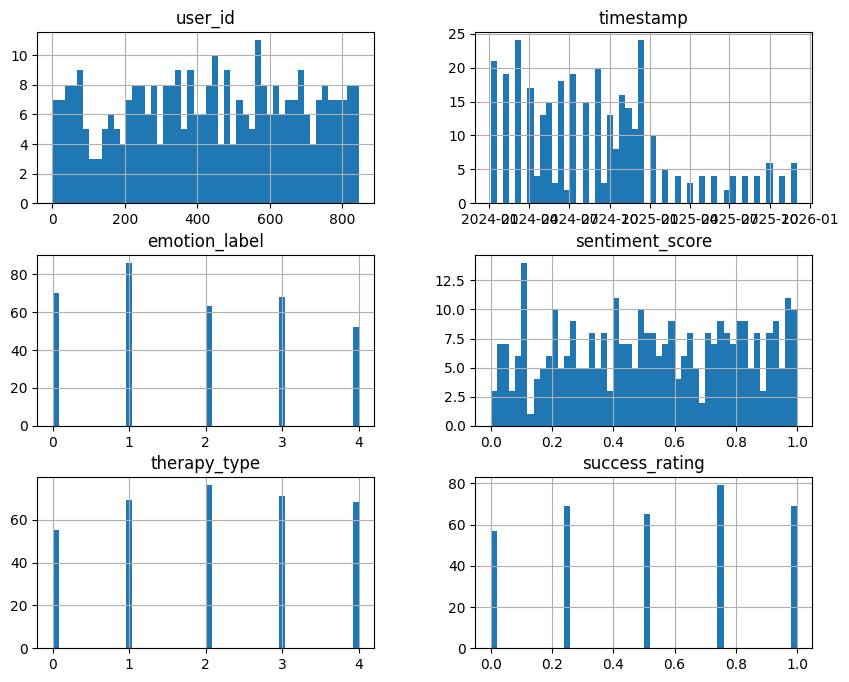

In [ ]:
# Import necessary visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Plot histograms for numerical features
# Changed 'data' to 'df'
df.hist(bins=50, figsize=(10, 8))
plt.show()

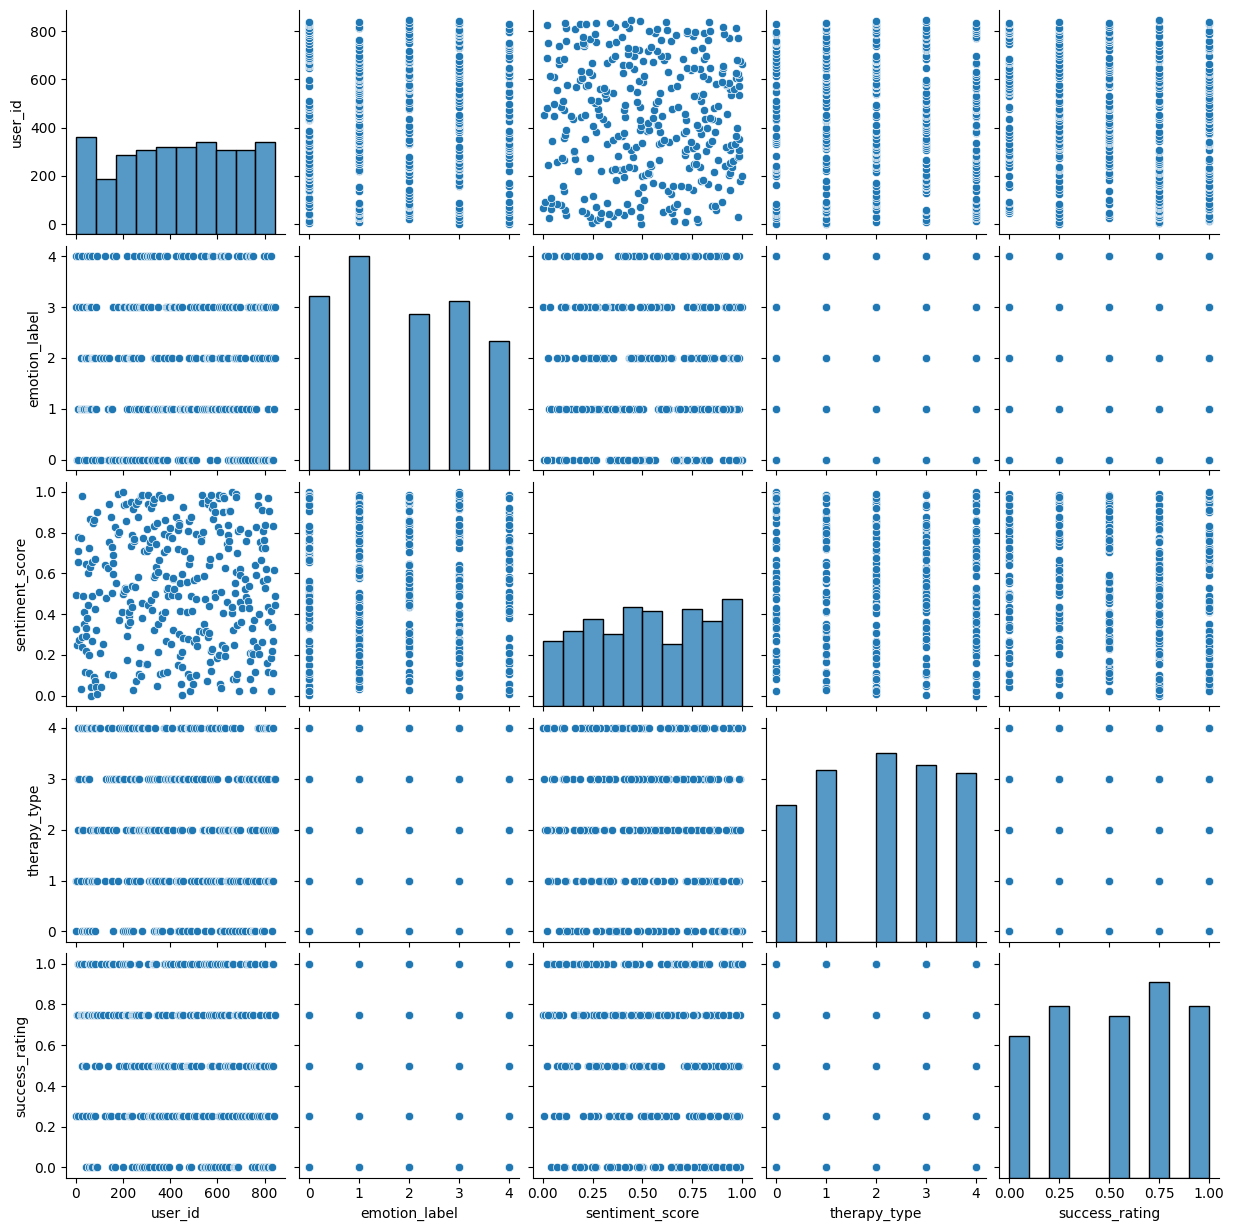

In [ ]:
# Pairplot to visualize relationships between features
sns.pairplot(df) # Changed 'data' to 'df'
plt.show()

In [ ]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler


In [ ]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling (Standardization)
scaler = StandardScaler()

NameError: name 'StandardScaler' is not defined

In [ ]:
# Select columns to scale
columns_to_scale = ['Reading', 'unit', 'CC Charge']

In [ ]:
# Fit and transform the data
# Check the actual column names in your DataFrame (df.columns)
# and adjust columns_to_scale accordingly.
# For example, if your columns are named 'reading', 'unit', and 'cc_charge':
columns_to_scale = ['sentiment_score', 'success_rating', 'emotion_label']  # Replace with your actual column names
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [ ]:
print("Data after scaling:")
print(df.head()) # Changed 'data' to 'df'

Data after scaling:
   user_id  timestamp                         user_input  emotion_label  \
0        1 2024-04-09   I feel so overwhelmed with work.       1.579693   
1        2 2024-05-04    I feel lonely and disconnected.       0.848114   
5        6 2024-01-10   I feel so overwhelmed with work.      -1.346624   
8        9 2025-09-01  I feel happy and motivated today!      -0.615045   
9       10 2025-05-02  I feel stressed about the future.       1.579693   

   sentiment_score  therapy_type  success_rating  
0        -0.106195             1       -0.795470  
1        -0.683735             0       -0.795470  
5        -0.963755             1        0.650451  
8         0.873874             2       -0.795470  
9         0.646358             3        0.650451  


In [ ]:
#feature selection
# Import necessary libraries for feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_regression

In [ ]:
# Define the target variable
# Assuming 'therapy_type' is the intended target based on the data preprocessing
target = 'therapy_type'  # Target column

# Check the available columns in your DataFrame
print(df.columns)

# Adjust column names for dropping if needed
# For example, if 'Date of Reading' is actually 'timestamp':
features = df.drop(columns=[target, 'timestamp'])

Index(['user_id', 'timestamp', 'user_input', 'emotion_label',
       'sentiment_score', 'therapy_type', 'success_rating'],
      dtype='object')


In [ ]:
#feature selection
# Import necessary libraries for feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Define the target variable
# Assuming 'therapy_type' is the intended target based on the data preprocessing
target = 'therapy_type'  # Target column

# Check the available columns in your DataFrame
print(df.columns)

# Adjust column names for dropping if needed
# For example, if 'Date of Reading' is actually 'timestamp':
# Exclude 'therapy_notes' column from features if it exists
if 'therapy_notes' in df.columns:
    features = df.drop(columns=[target, 'timestamp', 'therapy_notes']) # Dropping 'therapy_notes'
else:
    features = df.drop(columns=[target, 'timestamp'])  # If 'therapy_notes' doesn't exist

# Ensure all features are numeric
features = features.select_dtypes(include=np.number) # Keep only numerical features

# Univariate Selection (Mutual Information)
# SelectKBest for feature selection
X = features  # Input features
y = df[target]  # Target variable  -- Changed 'data' to 'df'
mutual_info_selector = SelectKBest(mutual_info_regression, k=2)  # Select top 2 features
X_kbest = mutual_info_selector.fit_transform(X, y)

Index(['user_id', 'timestamp', 'user_input', 'emotion_label',
       'sentiment_score', 'therapy_type', 'success_rating'],
      dtype='object')


In [ ]:
# Get selected features
selected_features_mutual_info = X.columns[mutual_info_selector.get_support()]

print("Selected features using Mutual Information:", selected_features_mutual_info)

Selected features using Mutual Information: Index(['sentiment_score', 'success_rating'], dtype='object')


In [ ]:
# Create a new DataFrame with the selected features for training
X_selected = pd.DataFrame(X_kbest, columns=selected_features_mutual_info)
print("Data with selected features:")
print(X_selected.head())

Data with selected features:
   sentiment_score  success_rating
0        -0.106195       -0.795470
1        -0.683735       -0.795470
2        -0.963755        0.650451
3         0.873874       -0.795470
4         0.646358        0.650451


In [ ]:
# modeling
# Import necessary libraries for modeling
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
# Dictionary to store model performance and predictions
model_performance = {}
model_predictions = {}

In [ ]:
# modeling
# Import necessary libraries for modeling
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split # This line imports train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
# modeling
# Import necessary libraries for modeling
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split # This line imports train_test_split
from sklearn.metrics import mean_squared_error

# Assuming X_selected and y are defined from previous steps
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42) # Adjust test_size and random_state as needed

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
model_performance['Linear Regression'] = lr_mse
model_predictions['Linear Regression'] = lr_pred

In [ ]:
# Decision Tree Regressor
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_pred)
model_performance['Decision Tree Regressor'] = dt_mse
model_predictions['Decision Tree Regressor'] = dt_pred

In [ ]:
# RandomForest Regressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
model_performance['RandomForest Regressor'] = rf_mse
model_predictions['RandomForest Regressor'] = rf_pred

In [ ]:
# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_pred)
model_performance['Gradient Boosting Regressor'] = gb_mse
model_predictions['Gradient Boosting Regressor'] = gb_pred

In [ ]:
# Support Vector Regressor (SVR)
svr_model = SVR()
svr_model.fit(X_train, y_train)
svr_pred = svr_model.predict(X_test)
svr_mse = mean_squared_error(y_test, svr_pred)
model_performance['Support Vector Regressor'] = svr_mse
model_predictions['Support Vector Regressor'] = svr_pred


In [ ]:
# Display model performance
for model, mse in model_performance.items():
    print(f"{model}: Mean Squared Error = {mse}")

Linear Regression: Mean Squared Error = 1.9142107630333731
Decision Tree Regressor: Mean Squared Error = 1.9775025386833978
RandomForest Regressor: Mean Squared Error = 1.956591031696614
Support Vector Regressor: Mean Squared Error = 1.9841569224553461


In [ ]:
# View the dataset with predictions from the best model (choose model with the lowest MSE)
best_model = min(model_performance, key=model_performance.get)
print(f"\nBest Model: {best_model} with MSE = {model_performance[best_model]}")



Best Model: Linear Regression with MSE = 1.9142107630333731


In [ ]:
# Adding predictions to the test dataset
X_test_with_predictions = X_test.copy()
X_test_with_predictions['Actual'] = y_test
X_test_with_predictions['Predicted'] = model_predictions[best_model]


In [ ]:
# Display the dataset with actual and predicted values
print("\nDataset with Actual and Predicted values:")
print(X_test_with_predictions.head())


Dataset with Actual and Predicted values:
     emotion_label  success_rating  Actual  Predicted
284      -1.346624        0.650451     NaN   2.166542
116      -1.346624       -0.072509     2.0   2.071670
113       0.848114        0.650451     NaN   2.186937
42        1.579693        0.650451     0.0   2.193735
126       0.116535        1.373412     NaN   2.275011


In [ ]:
# Import necessary library for plotting
import matplotlib.pyplot as plt
import seaborn as sns

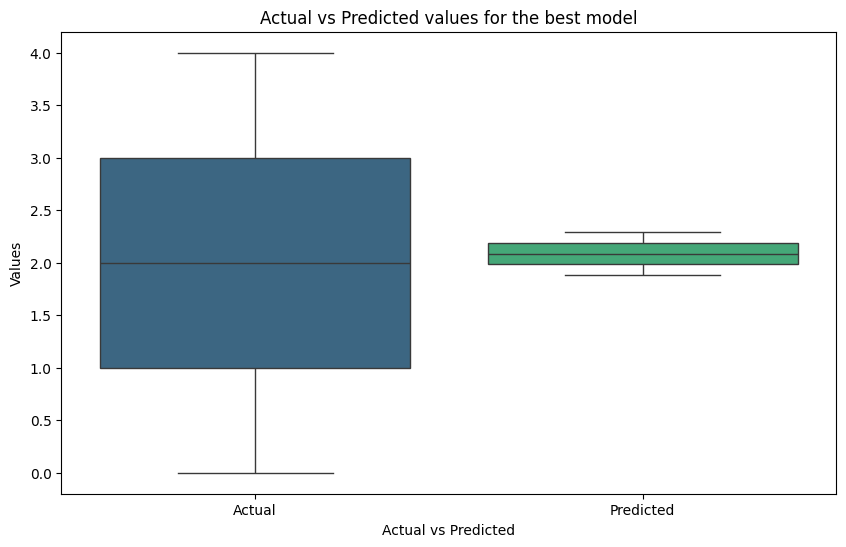

In [ ]:
# Box Plot: Actual vs Predicted values for the best model
plt.figure(figsize=(10, 6))
sns.boxplot(data=[y_test, model_predictions[best_model]], palette='viridis')
plt.xlabel('Actual vs Predicted')
plt.ylabel('Values')
plt.title('Actual vs Predicted values for the best model')
plt.xticks([0, 1], ['Actual', 'Predicted'])
plt.show()

In [ ]:
# Scatter Plot: Actual vs Predicted values for the best model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=model_predictions[best_model], palette='viridis')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted values for the best model')
plt.show()

In [ ]:
# Residual Plot: Residuals of the best model
residuals = y_test - model_predictions[best_model]
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, palette='viridis')
plt.xlabel('Residuals')
plt.title('Residuals of the best model')
plt.show()

NameError: name 'y_test' is not defined

In [ ]:
!pip install vaderSentiment
import nltk
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00


In [ ]:
# Download NLTK requirements
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# Initialize sentiment analysis tools
vader = SentimentIntensityAnalyzer()
emotion_model = pipeline("text-classification", model="bhadresh-savani/distilbert-base-uncased-emotion", top_k=1)

def analyze_sentiment(text):
    """Function to analyze sentiment using TextBlob, VADER, and BERT."""


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# Initialize sentiment analysis tools
vader = SentimentIntensityAnalyzer()
emotion_model = pipeline("text-classification", model="bhadresh-savani/distilbert-base-uncased-emotion", top_k=1)

def analyze_sentiment(text):
    """Function to analyze sentiment using TextBlob, VADER, and BERT."""
    # TextBlob Sentiment
    blob_score = TextBlob(text).sentiment.polarity  # -1 to 1

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
# Initialize sentiment analysis tools
vader = SentimentIntensityAnalyzer()
emotion_model = pipeline("text-classification", model="bhadresh-savani/distilbert-base-uncased-emotion", top_k=1)

def analyze_sentiment(text):
    """Function to analyze sentiment using TextBlob, VADER, and BERT."""
    # TextBlob Sentiment
    blob_score = TextBlob(text).sentiment.polarity  # -1 to 1

    # VADER Sentiment
    vader_score = vader.polarity_scores(text)['compound'] # -1 to 1

    # BERT Emotion Detection
    bert_emotion = emotion_model(text)[0][0]['label']

    # Return VADER score for sentiment and BERT emotion label
    return vader_score, bert_emotion

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
def suggest_therapy(sentiment, emotion):
    """Suggest therapy based on sentiment and emotion category."""
    therapy_recommendations = {
        "negative": "Cognitive Behavioral Therapy (CBT):Helps manage frustration and reframe negative thoughts.",
        "depression": "Counseling: A therapist can help explore deep emotions and provide guidance.",
        "anxiety": "Mindfulness Therapy: Meditation and grounding techniques can help ease anxiety.",
        "Joy": "Self-Care: Keep engaging in activities that bring happiness and fulfillment.",
        "insomnia": "Social Support: Connecting with loved ones and expressing gratitude enhances well-being.",
        "lonelimess": "Counseling: A therapist can help explore the root of negative reactions and resolve them."
    }

    # Fix: Use proper dictionary lookup to get recommendation
    # If sentiment or emotion is not found in the dictionary, provide a default suggestion
    recommendation = therapy_recommendations.get(sentiment.lower(), "Consider exploring different therapy options.") # Using sentiment.lower() for case-insensitive matching
    recommendation = therapy_recommendations.get(emotion.lower(), recommendation) # Using emotion.lower() for case-insensitive matching

    return recommendation # Return the recommendation

In [ ]:
def suggest_therapy(sentiment, emotion):
    """Suggest therapy based on sentiment and emotion category."""
    therapy_recommendations = {
        "Anger": "Cognitive Behavioral Therapy (CBT): Helps manage frustration and reframe negative thoughts.",
        "depression": "Counseling: A therapist can help explore deep emotions and provide guidance.",
        "anxitey": "Mindfulness Therapy: Meditation and grounding techniques can help ease anxiety.",
        "Joy": "Self-Care: Keep engaging in activities that bring happiness and fulfillment.",
        "Love": "Social Support: Connecting with loved ones and expressing gratitude enhances well-being.",
        "Surprise": "ACT Therapy: Helps in processing unexpected situations without stress.",
        "loneliness": "Counseling: A therapist can help explore the root of negative reactions and resolve them."
    }

    return therapy_recommendations.get(emotion, "General Therapy: Discuss your feelings with a professional.")



In [ ]:
# Get user input
user_text = input("Describe your current emotions: ")

Describe your current emotions: happy


In [ ]:
# Run Sentiment Analysis & Therapy Recommendation
sentiment, emotion = analyze_sentiment(user_text)
therapy_suggestion = suggest_therapy(sentiment, emotion)

In [ ]:
# Output
print(f"\nSentiment Analysis Result: {sentiment} ({emotion})")
print(f"Suggested Therapy: {therapy_suggestion}")


Sentiment Analysis Result: 0.5719 (joy)
Suggested Therapy: General Therapy: Discuss your feelings with a professional.
